In [11]:
#===================================================================================\
# Count number of distinct txs in logs
#===================================================================================\\
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from datetime import datetime


# ---------------------------------------------------------
# STEP 1: CONFIGURATION
# ---------------------------------------------------------
# Path to the directory containing the log files
# Use the variable appropriate for your test case
empty_blocks = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_17-35-00_to_2026-01-15_17-50-00/'
test_490_txs = '/home/christos/shielded/jupyter/2026-01-14/all_logs/'
new_100_txs = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_21-30-50_to_2026-01-15_21-34-35/'
new_200_txs = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_21-38-08_to_2026-01-15_21-44-01/'
txs_91_investigating_io = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-20_17-17-16_to_2026-01-20_17-21-40/'

# Set active log directory here
LOG_DIR = '/Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-20_13-21-00_to_2026-01-20_13-26-00/'

RELAYS = ["ferdie", "george", "henry", "iris", "jack", "paul", "quinn", "rita", "sam", "tom"]
BLOCK_PRODUCERS = ["alice", "bob", "charlie", "dave", "eve", "kate", "leo", "mike", "nina", "oliver"]
NODES = RELAYS + BLOCK_PRODUCERS

# ---------------------------------------------------------
# STEP 2: DEFINE PARSING LOGIC
# ---------------------------------------------------------

def count_validated_transactions(log_directory, nodes):
    """
    Reads log files and counts unique 'Validated Midnight transaction' entries
    using regex. Returns a set of all unique TXs and a dict of counts per node.
    """
    total_unique_txs = set()
    node_stats = {}
    files_processed = 0

    # Regex matches: Validated Midnight transaction "618804..."
    tx_pattern = re.compile(r'Validated Midnight transaction "([a-fA-F0-9]+)"')

    print(f"Scanning logs in: {log_directory}\n")

    for node in nodes:
        file_path = os.path.join(log_directory, f"{node}.txt")
        node_unique_txs = set()
        
        if not os.path.exists(file_path):
            # If file doesn't exist, we just record 0 for this node
            node_stats[node] = 0
            # print(f"⚠️ Log file not found for: {node}") # Optional warning
            continue

        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    match = tx_pattern.search(line)
                    if match:
                        tx_hash = match.group(1)
                        node_unique_txs.add(tx_hash)
            
            # Update stats
            node_stats[node] = len(node_unique_txs)
            total_unique_txs.update(node_unique_txs)
            files_processed += 1
            
        except Exception as e:
            print(f"Error reading file for {node}: {e}")
            node_stats[node] = 0

    return total_unique_txs, node_stats, files_processed

# ---------------------------------------------------------
# STEP 3: RUN ANALYSIS
# ---------------------------------------------------------

unique_tx_set, node_counts, files_count = count_validated_transactions(LOG_DIR, NODES)

# Print per-node statistics
for node in NODES:
    count = node_counts.get(node, 0)
    print(f"{node}: {count} distinct Validated transactions")

TOTAL_UNIQUE_TXS = len(unique_tx_set)
print("\n" + "=" * 50)
print(f"TOTAL DISTINCT TRANSACTIONS ACROSS ALL NODES: {TOTAL_UNIQUE_TXS}")
print("=" * 50)


Scanning logs in: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-20_13-21-00_to_2026-01-20_13-26-00/

ferdie: 180 distinct Validated transactions
george: 180 distinct Validated transactions
henry: 180 distinct Validated transactions
iris: 180 distinct Validated transactions
jack: 180 distinct Validated transactions
paul: 180 distinct Validated transactions
quinn: 180 distinct Validated transactions
rita: 180 distinct Validated transactions
sam: 180 distinct Validated transactions
tom: 180 distinct Validated transactions
alice: 180 distinct Validated transactions
bob: 180 distinct Validated transactions
charlie: 180 distinct Validated transactions
dave: 180 distinct Validated transactions
eve: 180 distinct Validated transactions
kate: 180 distinct Validated transactions
leo: 180 distinct Validated transactions
mike: 180 distinct Validated transactions
nina: 180 distinct Validated transactions
oliver: 180 distinct Validated transactions

TOTAL DISTI

2. Scanning Block Producers for Active Window (Non-empty blocks)...
3. Scanning TxPool metrics for specific nodes: ['charlie', 'ferdie']...

 FINAL BENCHMARK RESULTS
Total Unique Validated TXs:  180
Active Duration:             119.18 seconds
--------------------------------------------------
Average TPS (Global):        1.51 TX/s
Peak Instantaneous TPS:      13.00 TX/s
Mempool Drain Rate:          1.56 TX/s
--------------------------------------------------
Max TXs in Single Block:     13
Max Mempool Depth:           180 txs
Avg Mempool Depth:           144.9 txs


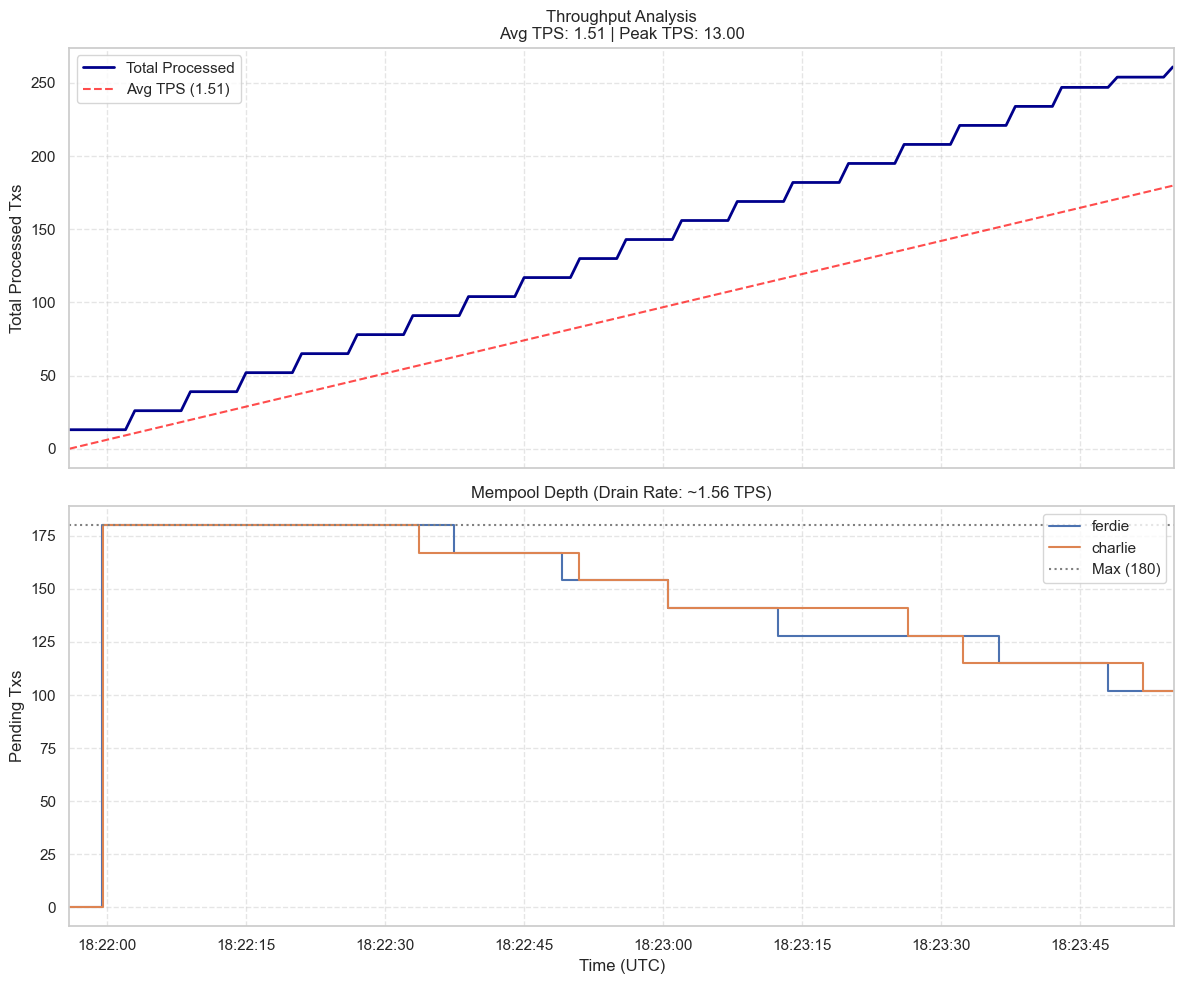

In [12]:
# Global list of nodes to check for TxPool metrics (Saves time/resources)
TX_POOL_NODES = ['charlie', 'ferdie']

# ==========================================
# PART 1: COUNT UNIQUE TRANSACTIONS
# ==========================================
# Already counted from previous code snipet and saved in TOTAL_UNIQUE_TXS


# ==========================================
# PART 2: DETERMINE ACTIVE TIME WINDOW
# ==========================================
def get_active_time_window(log_directory, producers):
    print("2. Scanning Block Producers for Active Window (Non-empty blocks)...")
    
    block_pattern = re.compile(r'Prepared block .* at (\d+) .* extrinsics_count: (\d+)')
    active_blocks = []

    for node in producers:
        file_path_txt = os.path.join(log_directory, f"{node}.txt")
        file_path_log = os.path.join(log_directory, f"{node}.log")
        file_path = file_path_txt if os.path.exists(file_path_txt) else file_path_log
        
        if not os.path.exists(file_path):
            continue

        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                match = block_pattern.search(line)
                if match:
                    count = int(match.group(2))
                    # Only consider blocks with > 2 transactions (System overhead correction)
                    if count > 2:
                        ts_str = line[:23]
                        try:
                            dt = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                            active_blocks.append({
                                'time': dt, 
                                'block_num': int(match.group(1)),
                                'tx_count': count - 2 
                            })
                        except ValueError:
                            continue

    if not active_blocks:
        return None

    df = pd.DataFrame(active_blocks)
    df = df.sort_values(by='time')
    return df

# ==========================================
# PART 3: GET TXPOOL (MEMPOOL) METRICS
# ==========================================
def get_mempool_stats(log_directory, nodes_to_scan):
    print(f"3. Scanning TxPool metrics for specific nodes: {nodes_to_scan}...")
    
    len_pattern = re.compile(r'mempool_len=(\d+)')
    json_pattern = re.compile(r'"numTxs":(\d+)')
    
    pool_data = []

    for node in nodes_to_scan: 
        file_path_txt = os.path.join(log_directory, f"{node}.txt")
        file_path_log = os.path.join(log_directory, f"{node}.log")
        file_path = file_path_txt if os.path.exists(file_path_txt) else file_path_log

        if not os.path.exists(file_path):
            continue

        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                count = -1
                m1 = len_pattern.search(line)
                if m1:
                    count = int(m1.group(1))
                else:
                    m2 = json_pattern.search(line)
                    if m2:
                        count = int(m2.group(1))
                
                if count > -1:
                    try:
                        ts_str = line[:23]
                        dt = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                        pool_data.append({'time': dt, 'node': node, 'pool_count': count})
                    except ValueError:
                        continue
                        
    return pd.DataFrame(pool_data)

# ==========================================
# PART 4: MAIN EXECUTION & PLOTTING
# ==========================================

# 1. Transactions Count
total_tx_count = TOTAL_UNIQUE_TXS

# 2. Active Window
df_blocks = get_active_time_window(LOG_DIR, BLOCK_PRODUCERS)

# 3. TxPool Metrics
df_pool = get_mempool_stats(LOG_DIR, TX_POOL_NODES) 

if df_blocks is not None and not df_blocks.empty:
    start_time = df_blocks['time'].min()
    end_time = df_blocks['time'].max()
    duration_seconds = (end_time - start_time).total_seconds()
    
    tps = total_tx_count / duration_seconds if duration_seconds > 0 else 0

    # Instantaneous TPS
    df_calc = df_blocks.copy()
    df_calc.set_index('time', inplace=True)
    tps_per_second = df_calc['tx_count'].resample('1s').sum().fillna(0)
    peak_instant_tps = tps_per_second.max()
    
    # --- NEW: MAX TXS IN SINGLE BLOCK ---
    max_tx_in_single_block = df_blocks['tx_count'].max()

    # --- Mempool Analysis & Drain Rate ---
    max_pool_depth = 0
    avg_pool_depth = 0
    drain_rate_tps = 0
    
    if not df_pool.empty:
        # Filter pool data to relevant window
        mask = (df_pool['time'] >= start_time) & (df_pool['time'] <= end_time)
        df_pool_window = df_pool.loc[mask]
        
        if not df_pool_window.empty:
            max_pool_depth = df_pool_window['pool_count'].max()
            avg_pool_depth = df_pool_window['pool_count'].mean()
            
            # CALCULATE DRAIN RATE
            peak_idx = df_pool_window['pool_count'].idxmax()
            peak_time = df_pool_window.loc[peak_idx, 'time']
            peak_val = df_pool_window.loc[peak_idx, 'pool_count']
            
            drain_duration = (end_time - peak_time).total_seconds()
            
            if drain_duration > 1:
                drain_rate_tps = peak_val / drain_duration

    print("\n" + "="*50)
    print(" FINAL BENCHMARK RESULTS")
    print("="*50)
    print(f"Total Unique Validated TXs:  {total_tx_count}")
    print(f"Active Duration:             {duration_seconds:.2f} seconds")
    print("-" * 50)
    print(f"Average TPS (Global):        {tps:.2f} TX/s")
    print(f"Peak Instantaneous TPS:      {peak_instant_tps:.2f} TX/s")
    print(f"Mempool Drain Rate:          {drain_rate_tps:.2f} TX/s")
    print("-" * 50)
    print(f"Max TXs in Single Block:     {max_tx_in_single_block}")
    print(f"Max Mempool Depth:           {max_pool_depth} txs")
    print(f"Avg Mempool Depth:           {avg_pool_depth:.1f} txs")
    print("="*50)

    # ==========================================
    # PLOTTING
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot 1: Throughput
    cumulative = tps_per_second.cumsum()
    ax1.plot(cumulative.index, cumulative.values, color='darkblue', linewidth=2, label='Total Processed')
    ax1.plot([start_time, end_time], [0, total_tx_count], 
             color='red', linestyle='--', alpha=0.7, label=f'Avg TPS ({tps:.2f})')
    
    ax1.set_title(f'Throughput Analysis\nAvg TPS: {tps:.2f} | Peak TPS: {peak_instant_tps:.2f}', fontsize=12)
    ax1.set_ylabel('Total Processed Txs')
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Mempool Depth
    if not df_pool.empty:
        df_pool = df_pool.sort_values('time')
        sns.lineplot(data=df_pool, x='time', y='pool_count', hue='node', ax=ax2, drawstyle='steps-post')
        ax2.axhline(max_pool_depth, color='grey', linestyle=':', label=f'Max ({max_pool_depth})')

    ax2.set_title(f'Mempool Depth (Drain Rate: ~{drain_rate_tps:.2f} TPS)', fontsize=12)
    ax2.set_ylabel('Pending Txs')
    ax2.set_xlabel('Time (UTC)')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.xlim(start_time, end_time)
    plt.tight_layout()
    plt.show()

else:
    print("No non-empty blocks found to calculate duration.")

Scanning for block creation events in: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-20_13-21-00_to_2026-01-20_13-26-00/
Found 38 blocks. Plotting...
Graph saved as 'block_creation_timeline.png'


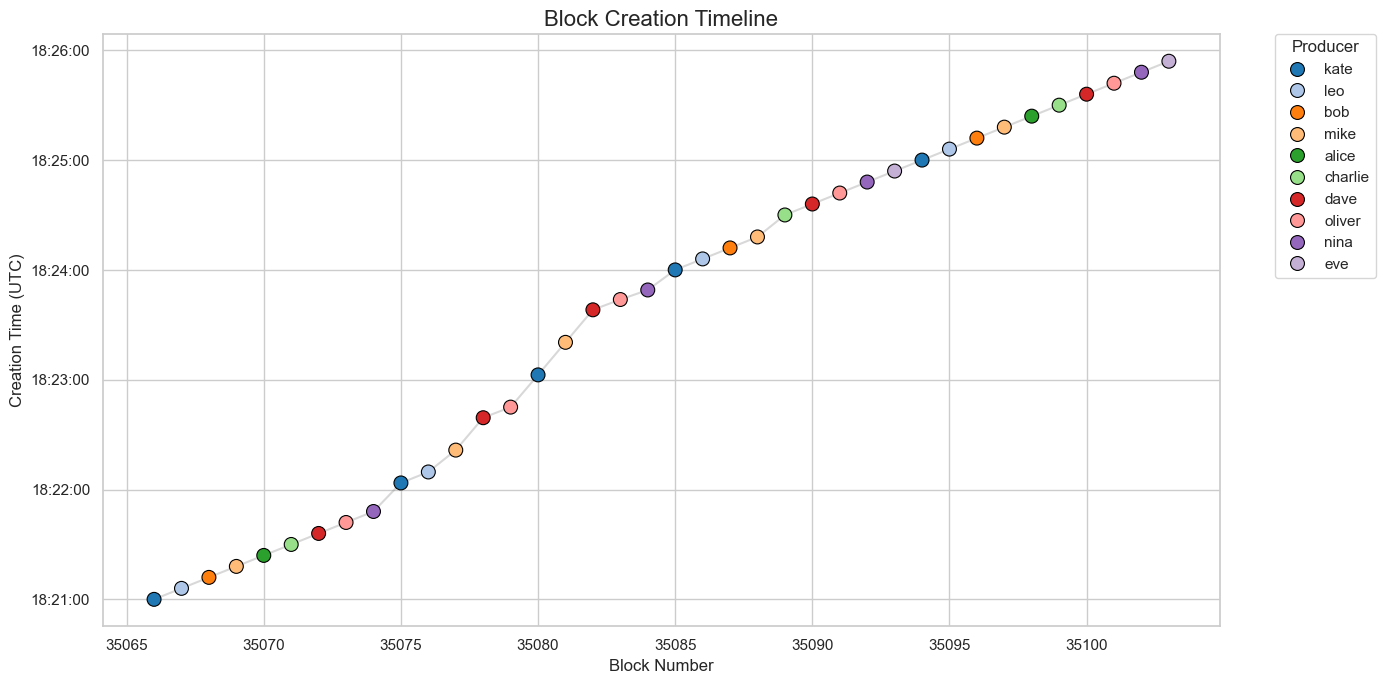

In [13]:
#===================================================================================\
# Plot block production timeline
#===================================================================================\\


# ---------------------------------------------------------
# STEP 4: PARSE BLOCK CREATION TIMES (Re-parsing for Timeline)
# ---------------------------------------------------------
# We need to scan the logs again specifically for block creation events 
# to build the creation_registry required for the plot.

creation_registry = {} 

# Regex to capture timestamp and creation event
timestamp_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+)")
creation_pattern = re.compile(r"Pre-sealed block for proposal at (\d+)")

print(f"Scanning for block creation events in: {LOG_DIR}")

for node in NODES:
    filepath = os.path.join(LOG_DIR, f"{node}.txt")
    
    if not os.path.exists(filepath):
        continue
        
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            
            # Check for creation line first (optimization)
            create_match = creation_pattern.search(line)
            if create_match:
                # Extract Timestamp
                ts_match = timestamp_pattern.search(line)
                if not ts_match: continue
                
                try:
                    ts_str = ts_match.group(1)
                    if len(ts_str.split('.')[-1]) > 6: ts_str = ts_str[:26]
                    current_time = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                    
                    block_num = int(create_match.group(1))
                    
                    # Store data
                    creation_registry[block_num] = {
                        'time': current_time,
                        'creator': node
                    }
                except ValueError:
                    continue

# ---------------------------------------------------------
# STEP 5: PLOT BLOCK CREATION TIMELINE
# ---------------------------------------------------------

if not creation_registry:
    print("No block creation events found. Check log path.")
else:
    # Convert registry to DataFrame
    creation_data = []
    for block_num, info in creation_registry.items():
        creation_data.append({
            "Block": block_num,
            "Timestamp": info['time'],
            "Creator": info['creator']
        })

    df_creation = pd.DataFrame(creation_data).sort_values("Block")

    print(f"Found {len(df_creation)} blocks. Plotting...")

    # Setup the Plot
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # 1. Draw a line to show the progression
    sns.lineplot(
        data=df_creation,
        x="Block",
        y="Timestamp",
        color="gray",
        alpha=0.3,
        zorder=1
    )

    # 2. Draw points colored by the Creator Node
    plot = sns.scatterplot(
        data=df_creation,
        x="Block",
        y="Timestamp",
        hue="Creator",
        palette="tab20",  # Colorful palette for many nodes
        s=100,            # Dot size
        edgecolor="black",
        zorder=2
    )

    # Format Y-Axis to show HH:MM:SS
    plot.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

    plt.title("Block Creation Timeline", fontsize=16)
    plt.xlabel("Block Number", fontsize=12)
    plt.ylabel("Creation Time (UTC)", fontsize=12)

    # Ensure integer ticks on X-axis if valid range
    if df_creation["Block"].nunique() < 20:
        plt.xticks(df_creation["Block"].unique())

    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Producer")
    
    plt.tight_layout()
    plt.savefig("block_creation_timeline.png", dpi=300)
    print("Graph saved as 'block_creation_timeline.png'")
    
    plt.show()

Parsed 50 blocks successfully.
    Node  Block  ProductionTime_ms  StartDelay_ms
0  Alice  35070               32.0           36.0
1  Alice  35077             3785.0           38.0
2  Alice  35081             2386.0           40.0
3  Alice  35088              939.0           40.0
4  Alice  35098               38.0           41.0


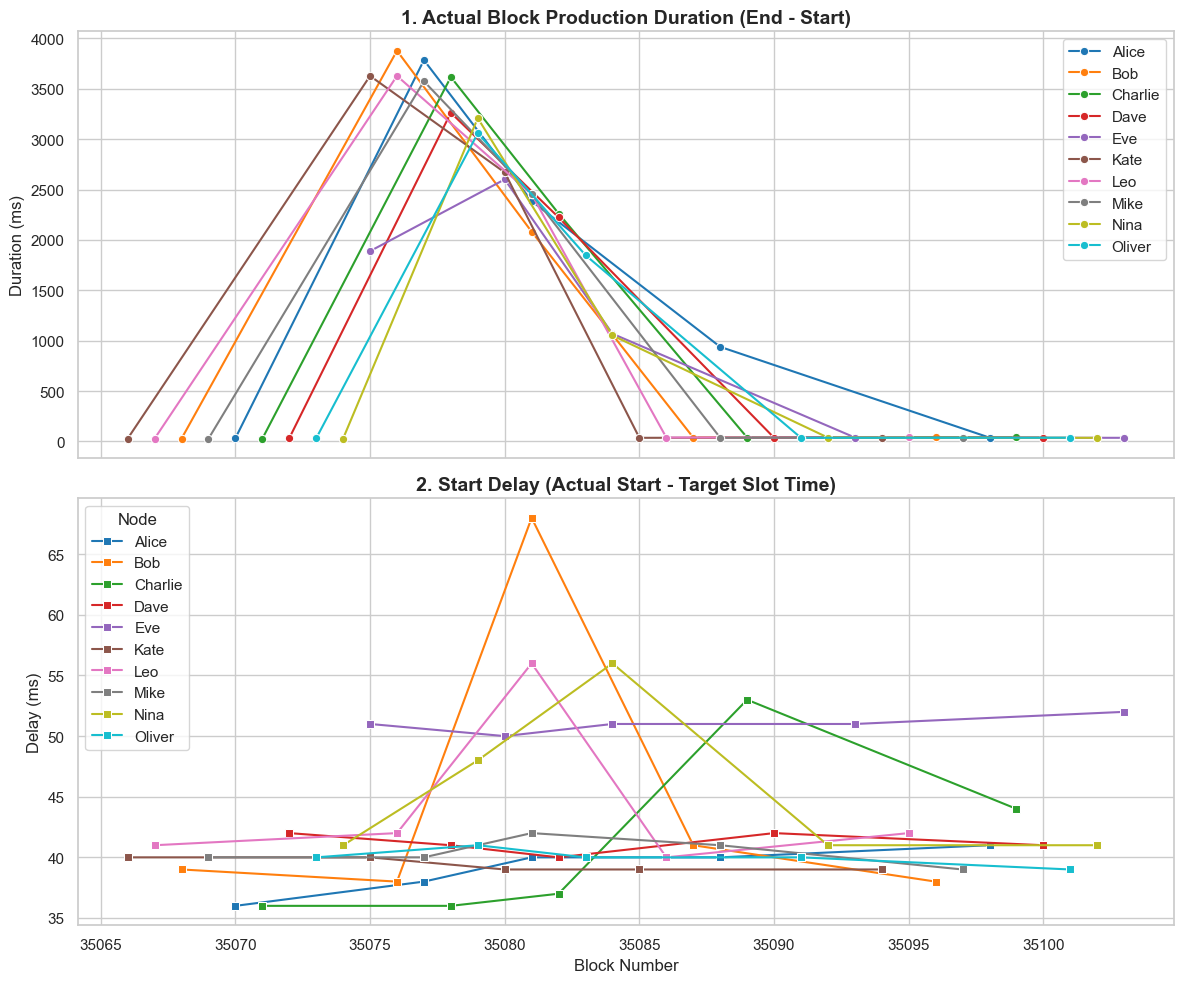

In [14]:
#===================================================================================
# Plot all Block Producer's block production time and the start delay
#===================================================================================

files_to_process = []
for node in BLOCK_PRODUCERS:
    # os.path.join automatically adds the '/' if LOG_DIR doesn't have it
    files_to_process.append(os.path.join(LOG_DIR, f"{node}.txt"))

# # ---------------------------------------------------------
# # STEP 6: PARSE THE LOGS
# # ---------------------------------------------------------

def parse_substrate_logs_robust(file_list):
    data = []
    
    # 1. Regex to capture Timestamp and the rest of the message
    # Matches: 2026-01-15 17:39:36.048  INFO ...
    base_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})\s+(.*)")
    
    # 2. Regex for START event (captures Parent Block #)
    # Matches: ... Starting consensus session on top of parent ... (#14406)
    start_pattern = re.compile(r"Starting consensus session on top of parent .* \(#(\d+)\)")
    
    # 3. Regex for END event (captures Current Block #)
    # Matches: ... Prepared block for proposing at 14407 ...
    end_pattern = re.compile(r"Prepared block for proposing at (\d+)")

    for filename in file_list:
        node_name = os.path.splitext(os.path.basename(filename))[0].capitalize()
        
        # Dictionary to store timestamps for each block
        # Structure: { 14407: {'start': datetime, 'end': datetime}, ... }
        block_events = {}
        
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                
                # Extract Timestamp
                base_match = base_pattern.search(line)
                if not base_match: continue
                
                timestamp_str = base_match.group(1)
                message = base_match.group(2)
                
                try:
                    current_time = datetime.strptime(timestamp_str, "%Y-%m-%d %H:%M:%S.%f")
                except ValueError:
                    continue

                # --- CHECK FOR START (Parent Block) ---
                start_match = start_pattern.search(message)
                if start_match:
                    parent_block = int(start_match.group(1))
                    # If we are working on top of 14406, we are building 14407
                    target_block = parent_block + 1
                    
                    if target_block not in block_events: block_events[target_block] = {}
                    block_events[target_block]['start'] = current_time
                    continue

                # --- CHECK FOR END (Current Block) ---
                end_match = end_pattern.search(message)
                if end_match:
                    target_block = int(end_match.group(1))
                    
                    if target_block not in block_events: block_events[target_block] = {}
                    block_events[target_block]['end'] = current_time
                    continue

        # --- CALCULATE DURATIONS ---
        # Now we iterate through the dictionary and calculate stats for blocks that have both times
        for block_num, times in block_events.items():
            if 'start' in times and 'end' in times:
                start_time = times['start']
                end_time = times['end']
                
                # A. Production Time
                # Calculate diff in milliseconds
                duration_ms = (end_time - start_time).total_seconds() * 1000
                
                # Sanity check: If duration is negative (rare clock skew?), skip
                if duration_ms < 0: continue

                # B. Start Delay (Ideal Target vs Actual Start)
                # Calculate seconds past the minute
                total_seconds = start_time.second + (start_time.microsecond / 1e6)
                remainder = total_seconds % 6 
                start_delay_ms = remainder * 1000
                
                data.append({
                    "Node": node_name,
                    "Block": block_num,
                    "ProductionTime_ms": duration_ms,
                    "StartDelay_ms": start_delay_ms
                })

    return pd.DataFrame(data)

# Run the parser
df = parse_substrate_logs_robust(files_to_process)

print(f"Parsed {len(df)} blocks successfully.")
if not df.empty:
    print(df.head())
else:
    print("No matching blocks found. Check log paths or regex.")

# ---------------------------------------------------------
# STEP 3: PLOT THE GRAPHS
# ---------------------------------------------------------

if not df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    sns.set_theme(style="whitegrid")

    # GRAPH 1: Production Time (Duration)
    # How long did the CPU actually churn to build the block?
    sns.lineplot(
        ax=axes[0],
        data=df, 
        x="Block", 
        y="ProductionTime_ms", 
        hue="Node", 
        marker="o",
        palette="tab10"
    )
    axes[0].set_title("1. Actual Block Production Duration (End - Start)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Duration (ms)")
    axes[0].legend(loc='upper right')

    # GRAPH 2: Start Delay
    # How long after the ideal 6s slot did the node start working?
    sns.lineplot(
        ax=axes[1],
        data=df, 
        x="Block", 
        y="StartDelay_ms", 
        hue="Node", 
        marker="s", # Square marker to distinguish
        palette="tab10"
    )
    axes[1].set_title("2. Start Delay (Actual Start - Target Slot Time)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Delay (ms)")
    axes[1].set_xlabel("Block Number")
    
    # Force Integer X-Axis
    if len(df) < 20:
        axes[1].set_xticks(sorted(df['Block'].unique()))

    plt.tight_layout()
    plt.savefig("block_timing_analysis.png")
    plt.show()
else:
    print("No matching log lines found. Check regex patterns.")

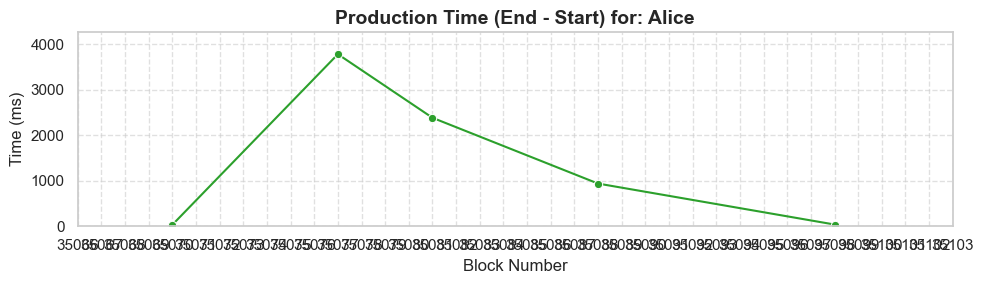

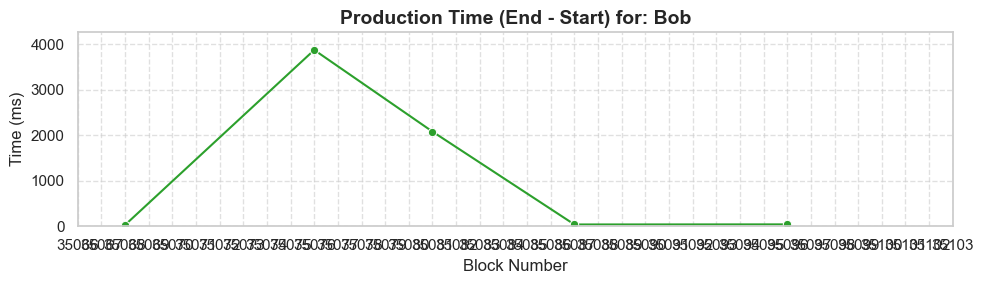

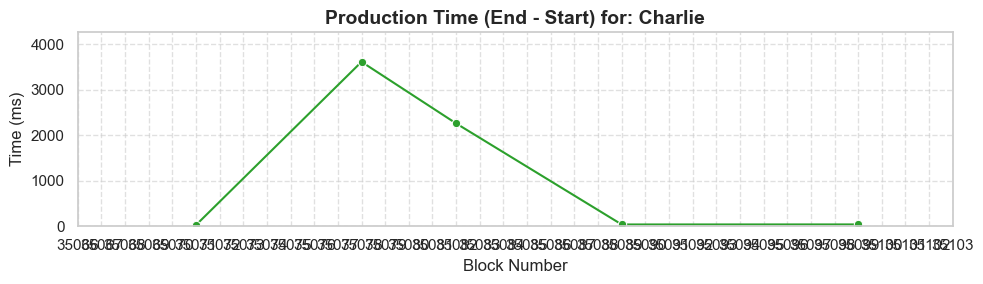

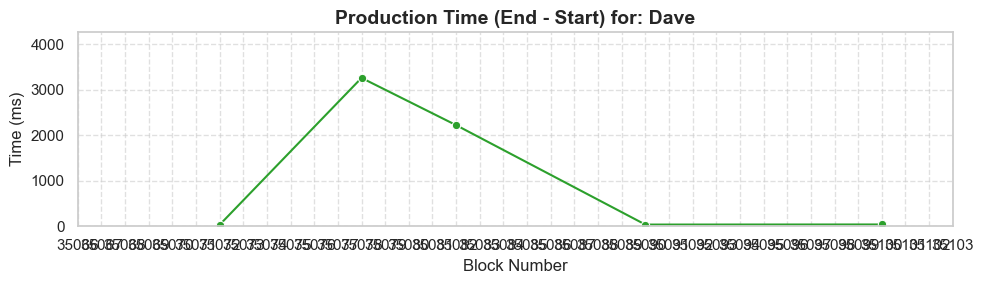

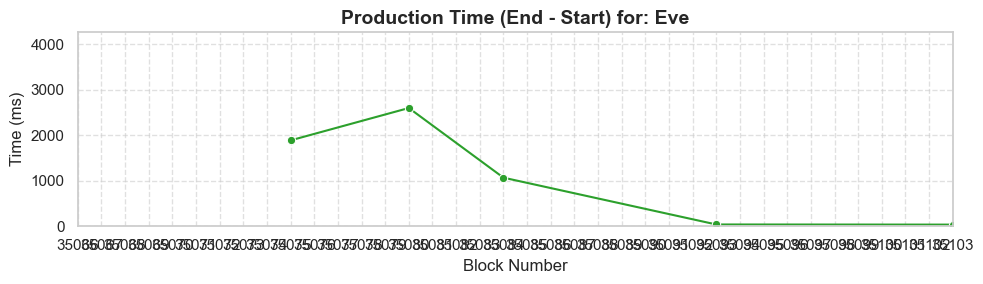

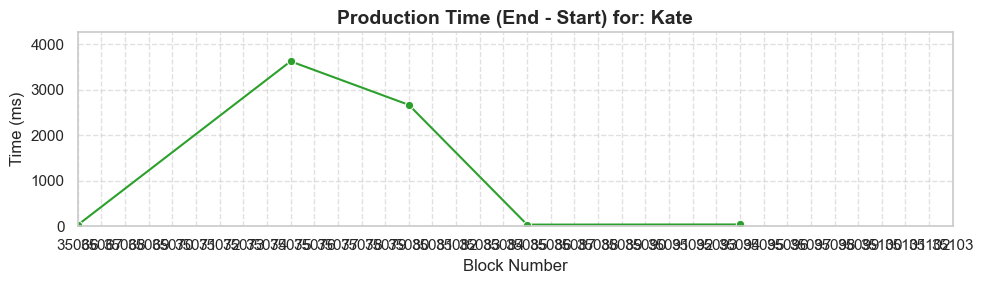

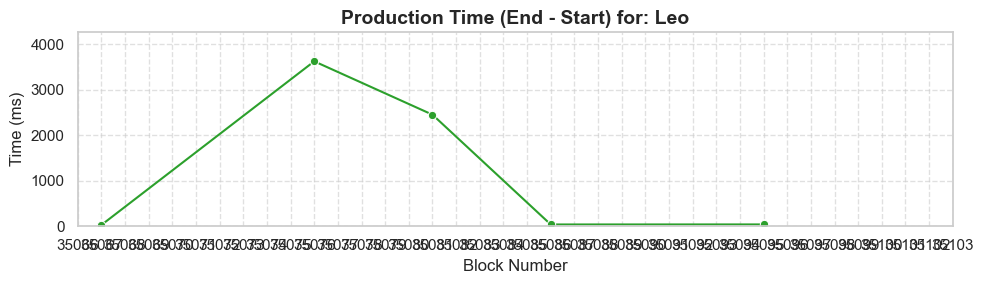

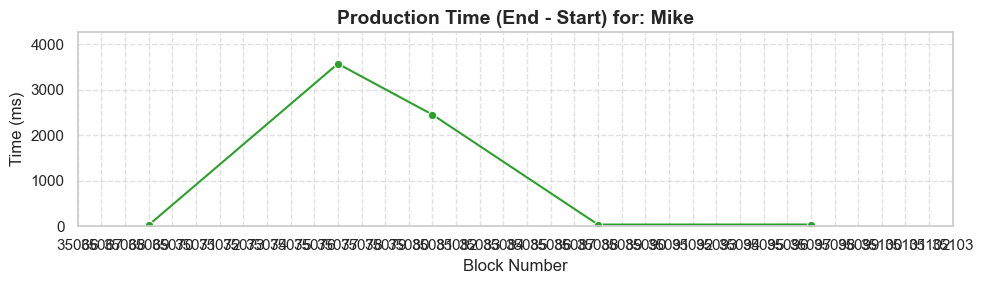

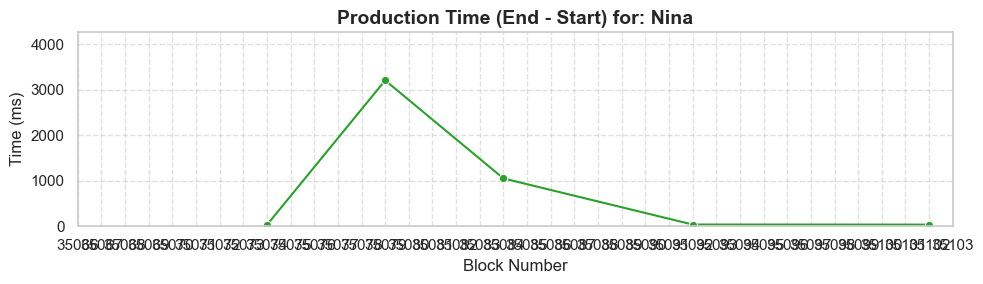

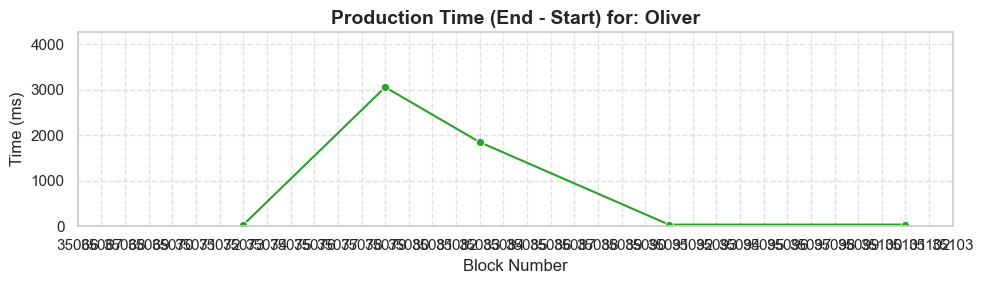

In [15]:
#===================================================================================
# Plot each Block Producer's block production time
#===================================================================================

# 1. Get the list of nodes
unique_nodes = sorted(df['Node'].unique())

# 2. Determine global X-axis limits
min_block = df['Block'].min()
max_block = df['Block'].max()

# 3. Determine global Y-axis limit (New Step)
# Find the max time across ALL nodes and add a 10% buffer for visual spacing
max_y_val = df['ProductionTime_ms'].max()
global_y_limit = max_y_val * 1.1 

# 4. Iterate and plot
for node in unique_nodes:
    # Filter data for this specific node
    node_data = df[df['Node'] == node]
    
    # Skip if no data for this node
    if node_data.empty:
        continue

    # Create a new figure for each node
    plt.figure(figsize=(10, 3))
    
    # Plot Production Time
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ProductionTime_ms", 
        marker="o", 
        color="#2ca02c"
    )
    
    # Formatting
    plt.title(f"Production Time (End - Start) for: {node}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # --- GLOBAL AXIS LIMITS ---
    # 1. Apply global X limits
    plt.xlim(min_block, max_block)
    
    # 2. Apply global Y limits (0 to Global Max)
    plt.ylim(0, global_y_limit)
    # --------------------------
    
    # Handle ticks: If the total range is small, show every integer. 
    if (max_block - min_block) < 50:
        plt.xticks(range(int(min_block), int(max_block) + 1))
        
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Reading logs from: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-20_13-21-00_to_2026-01-20_13-26-00/
Processing complete.
  - Unique Blocks Created: 50
  - Total Import Events: 976

Sample Data (First 5 rows):
     Block    Node  ImportTime_ms         Hash
0    35066  ferdie          185.0  0x8901…37be
100  35066   henry          168.0  0x8901…37be
149  35066    iris          165.0  0x8901…37be
198  35066    jack          168.0  0x8901…37be
247  35066    paul           71.0  0x8901…37be

Graph saved as 'import_times_hash_matched.png'


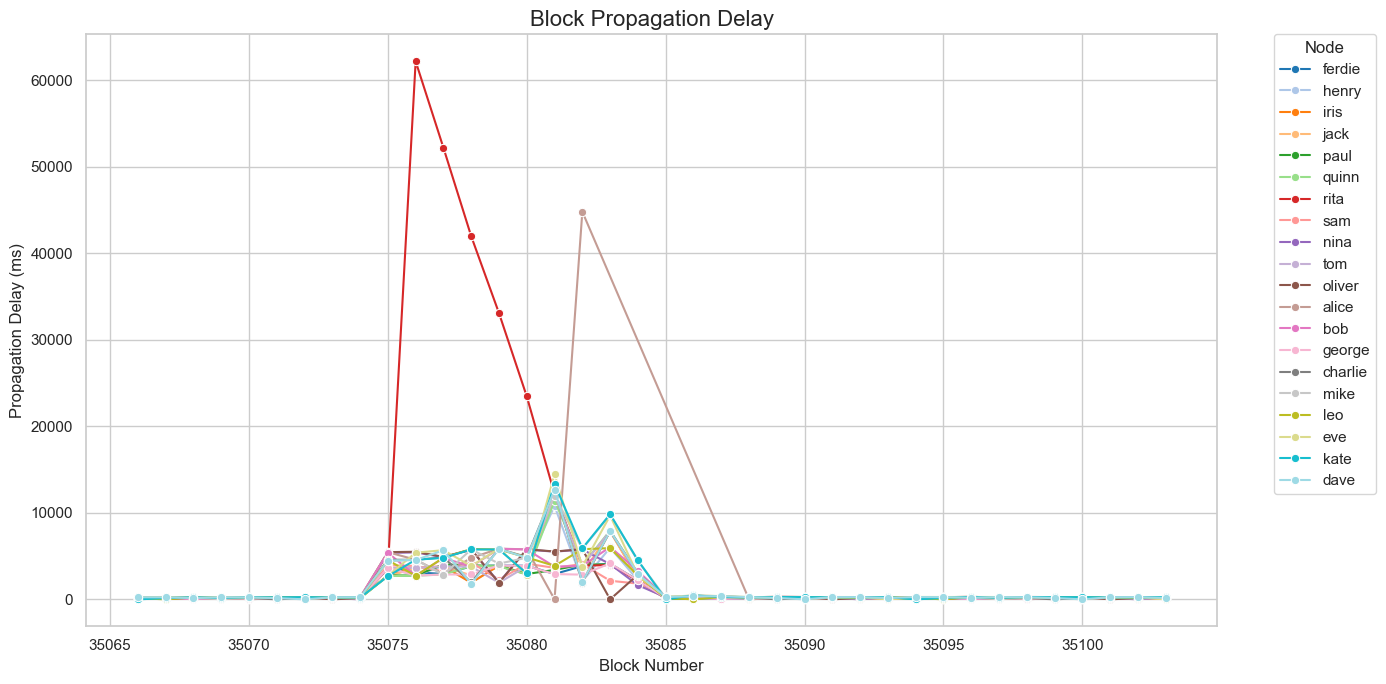

In [16]:
# ---------------------------------------------------------
# Plot all block import times
# ---------------------------------------------------------




# ---------------------------------------------------------
# STEP 2: HELPER FUNCTIONS
# ---------------------------------------------------------

def to_short_hash(full_hash):
    """
    Converts a full hash (e.g. 0xf2d38b...ed171) to the log format (0xf2d3…d171).
    Standard Substrate log format is usually: 0x + first 4 + … + last 4
    """
    if not full_hash.startswith("0x"):
        return full_hash
    
    # Remove 0x prefix for slicing
    clean = full_hash[2:]
    if len(clean) < 8: return full_hash
    
    return f"0x{clean[:4]}…{clean[-4:]}"

# ---------------------------------------------------------
# STEP 3: PARSE THE FILES
# ---------------------------------------------------------

# Dictionary to store creation times keyed by the BLOCK HASH (Short format)
# Key: ShortHash (str), Value: { 'time': datetime, 'block_num': int, 'node': str }
creation_registry = {}

# List to store raw import events to be processed later
# Item: { 'time': datetime, 'block_num': int, 'short_hash': str, 'node': str }
import_events = []

# Regex patterns
timestamp_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+)")

# Capture Creation: "Pre-sealed block for proposal at 3040. Hash now 0xf2d3..."
# We use the "Pre-sealed" line because it contains the final finalized hash.
creation_pattern = re.compile(r"Pre-sealed block for proposal at (\d+)\. Hash now (0x[a-fA-F0-9]+)")

# Capture Import: "Imported #3040 (0x4e7c…cc64 → 0xf2d3…d171)"
# We capture Group 1 (Block Num) and Group 2 (The second hash, which is the new block hash)
import_pattern = re.compile(r"Imported #(\d+) \(.*? → (0x[a-fA-F0-9…\.]+)\)")

print(f"Reading logs from: {LOG_DIR}")

for node in NODES:
    filepath = os.path.join(LOG_DIR, f"{node}.txt")
    
    if not os.path.exists(filepath):
        print(f"  - Warning: Log file not found for {node}")
        continue
        
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            
            # 1. Extract Timestamp
            ts_match = timestamp_pattern.search(line)
            if not ts_match: continue
            
            try:
                ts_str = ts_match.group(1)
                # Truncate microseconds if too long (Python limit)
                if len(ts_str.split('.')[-1]) > 6: ts_str = ts_str[:26] 
                current_time = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
            except ValueError:
                continue 

            # 2. Check for BLOCK CREATION (The Source of Truth)
            create_match = creation_pattern.search(line)
            if create_match:
                block_num = int(create_match.group(1))
                full_hash = create_match.group(2)
                short_hash = to_short_hash(full_hash)
                
                # We store this hash as the canonical creation event
                creation_registry[short_hash] = {
                    'time': current_time,
                    'block_num': block_num,
                    'creator': node
                }
                continue

            # 3. Check for BLOCK IMPORT
            import_match = import_pattern.search(line)
            if import_match:
                block_num = int(import_match.group(1))
                imported_hash = import_match.group(2)
                
                import_events.append({
                    'time': current_time,
                    'block_num': block_num,
                    'short_hash': imported_hash,
                    'node': node
                })

print(f"Processing complete.")
print(f"  - Unique Blocks Created: {len(creation_registry)}")
print(f"  - Total Import Events: {len(import_events)}")

# ---------------------------------------------------------
# STEP 4: CALCULATE LATENCY (MATCHING BY HASH)
# ---------------------------------------------------------

data = []

for event in import_events:
    target_hash = event['short_hash']
    importer = event['node']
    import_time = event['time']
    
    # Only calculate if we have a creation record for THIS SPECIFIC HASH
    if target_hash in creation_registry:
        genesis_info = creation_registry[target_hash]
        creation_time = genesis_info['time']
        creator = genesis_info['creator']
        block_num = genesis_info['block_num']
        
        # If this node is the creator, latency is 0
        if importer == creator:
            delay_ms = 0.0
        else:
            delta = import_time - creation_time
            delay_ms = delta.total_seconds() * 1000.0
        
        data.append({
            "Block": block_num,
            "Node": importer,
            "ImportTime_ms": delay_ms,
            "Hash": target_hash
        })

# ---------------------------------------------------------
# STEP 5: PLOT
# ---------------------------------------------------------

if not data:
    print("No matching hash data found! Check if the log format matches the patterns.")
else:
    df = pd.DataFrame(data)
    df = df.sort_values(by="Block")
    
    # Display sample to verify
    print("\nSample Data (First 5 rows):")
    print(df.head())

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=df, 
        x="Block", 
        y="ImportTime_ms", 
        hue="Node", 
        marker="o",
        palette="tab20", 
        linewidth=1.5,
        errorbar=None 
    )

    plt.title("Block Propagation Delay", fontsize=16)
    plt.xlabel("Block Number", fontsize=12)
    plt.ylabel("Propagation Delay (ms)", fontsize=12)
    
    # Formatting X-axis
    if df["Block"].nunique() < 20:
        plt.xticks(df["Block"].unique())

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Node")
    plt.tight_layout()
    
    plt.savefig("import_times_hash_matched.png", dpi=300)
    print("\nGraph saved as 'import_times_hash_matched.png'")
    
    plt.show()

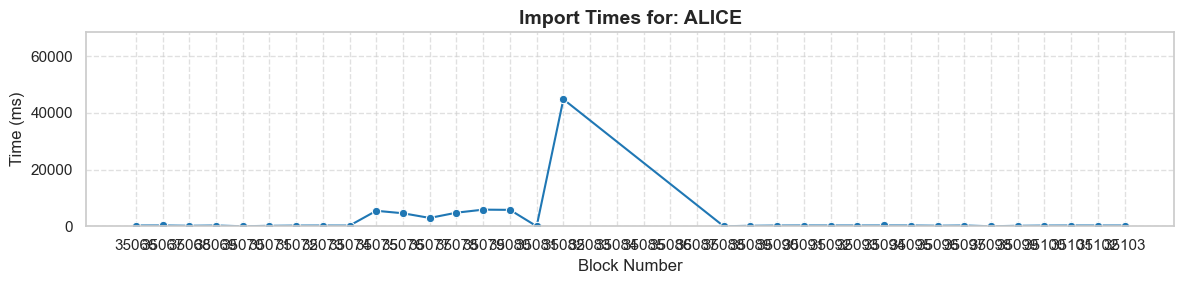

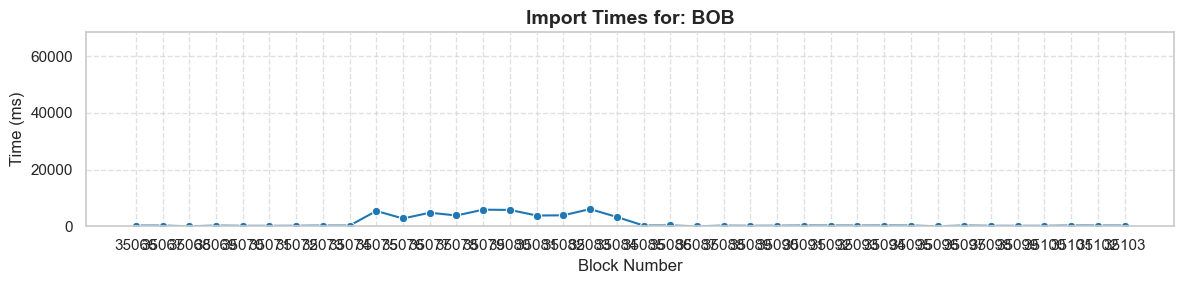

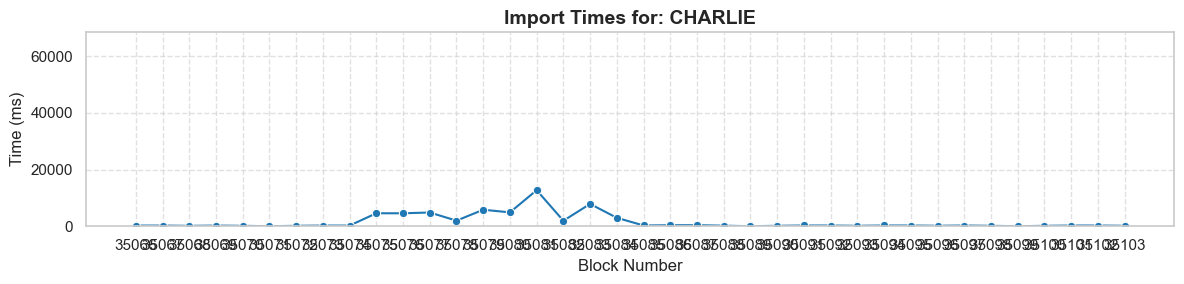

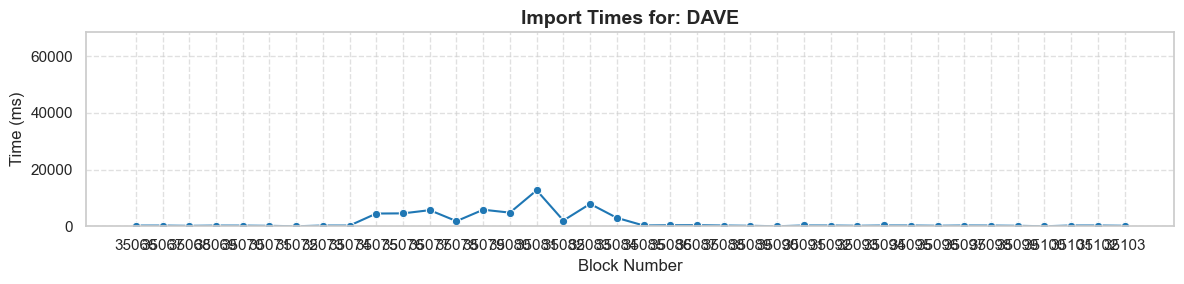

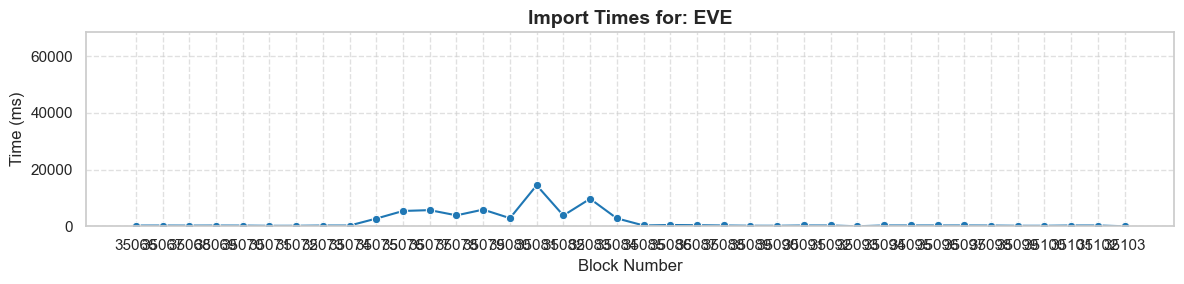

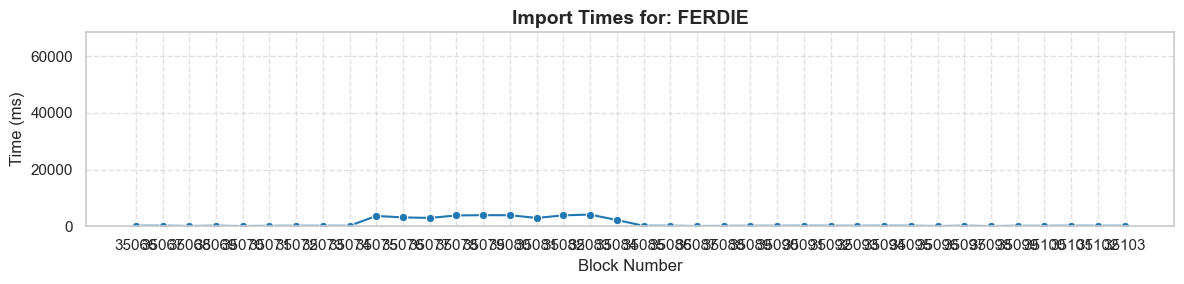

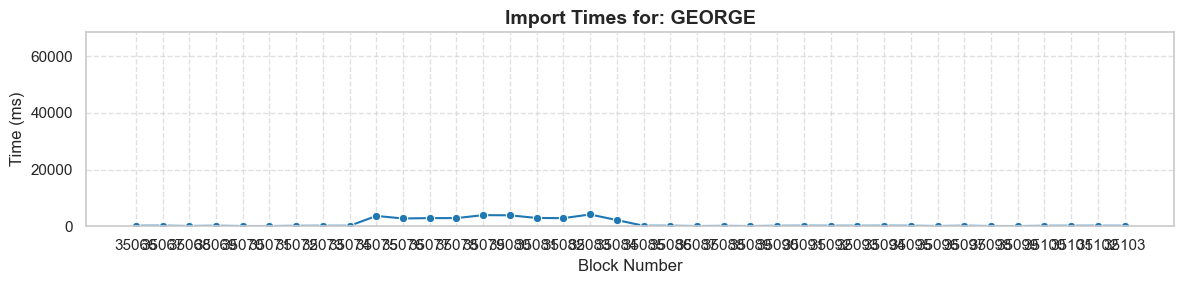

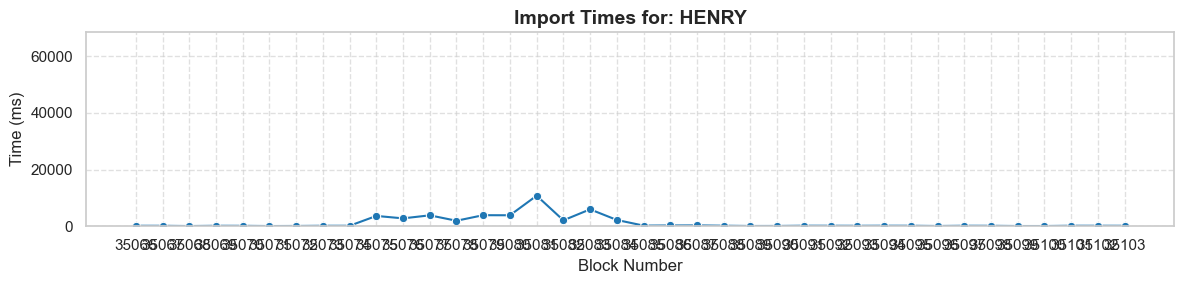

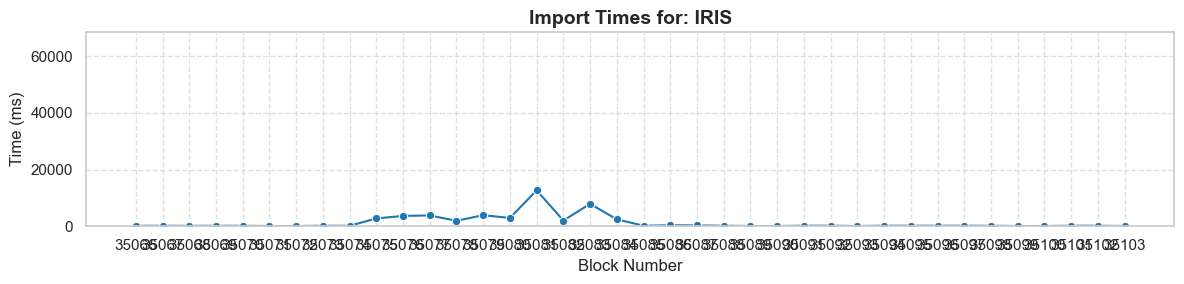

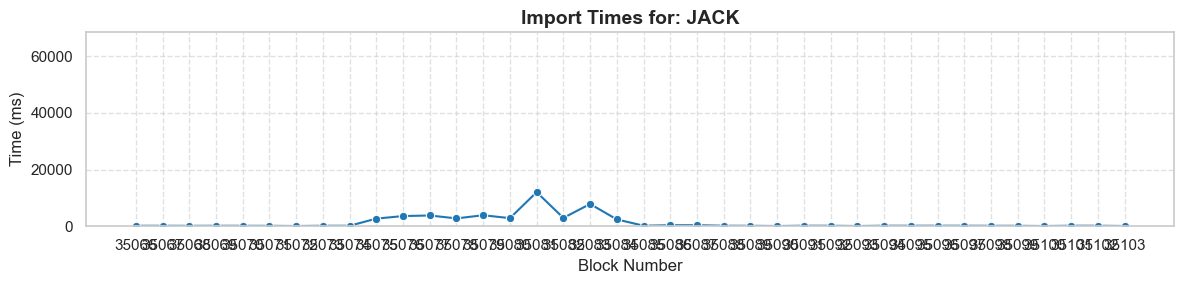

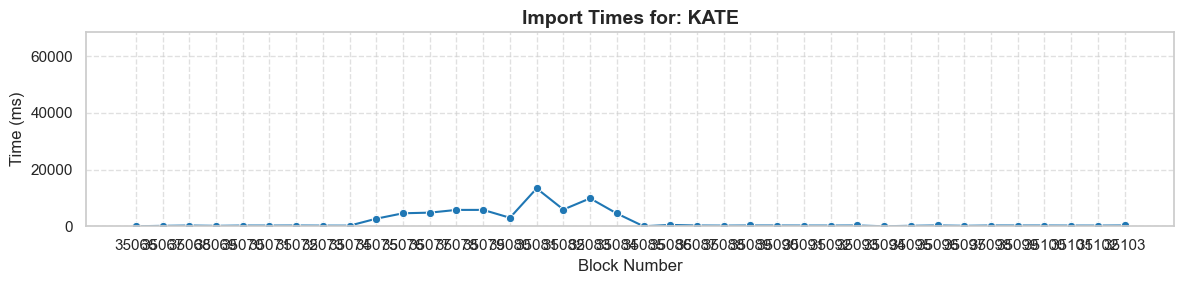

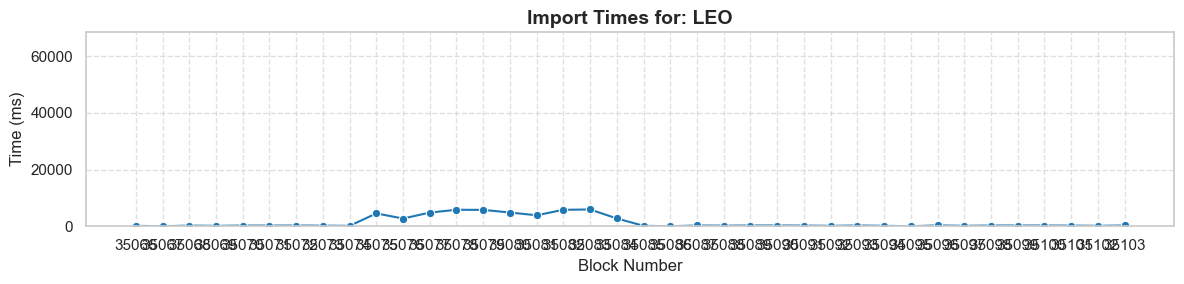

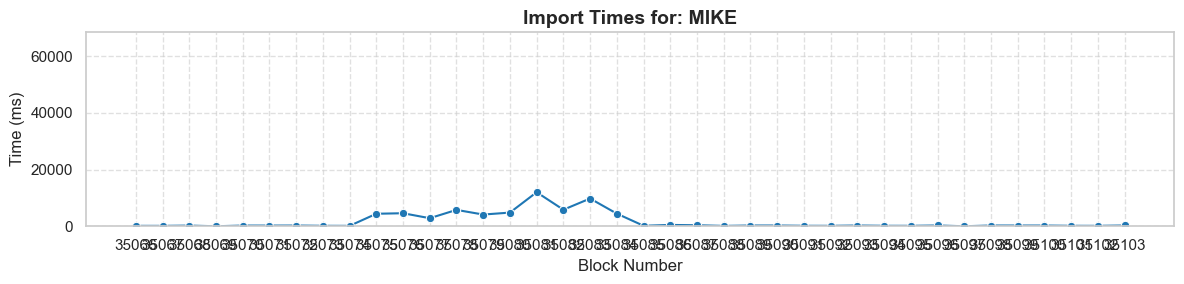

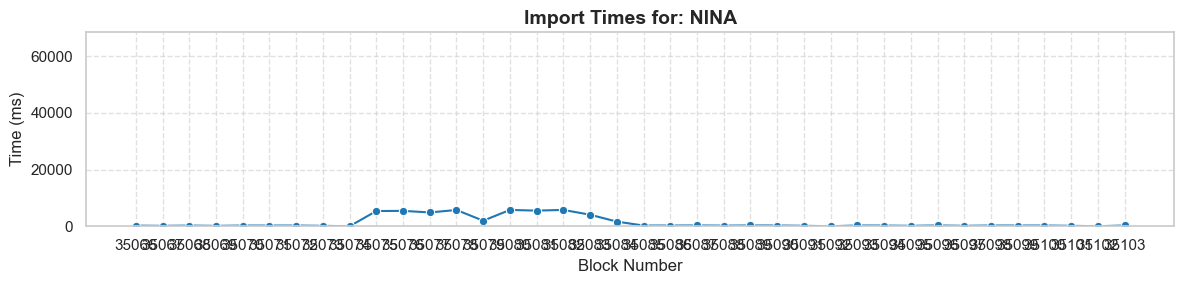

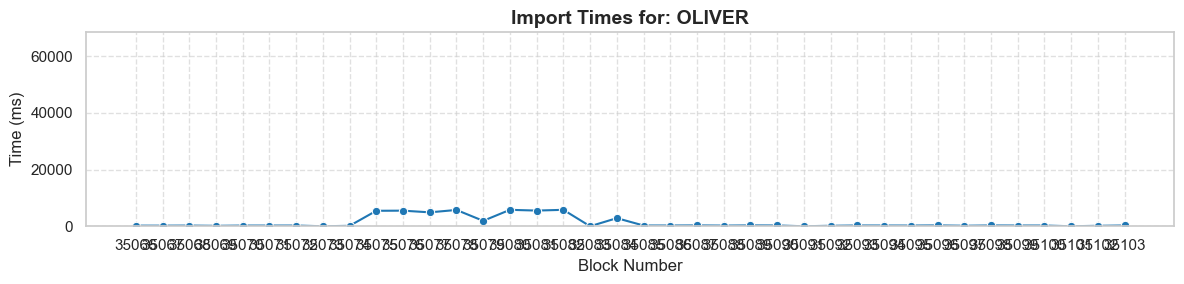

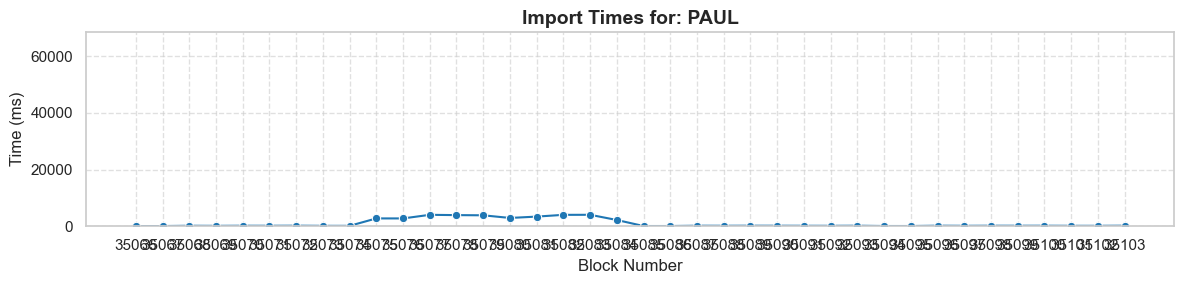

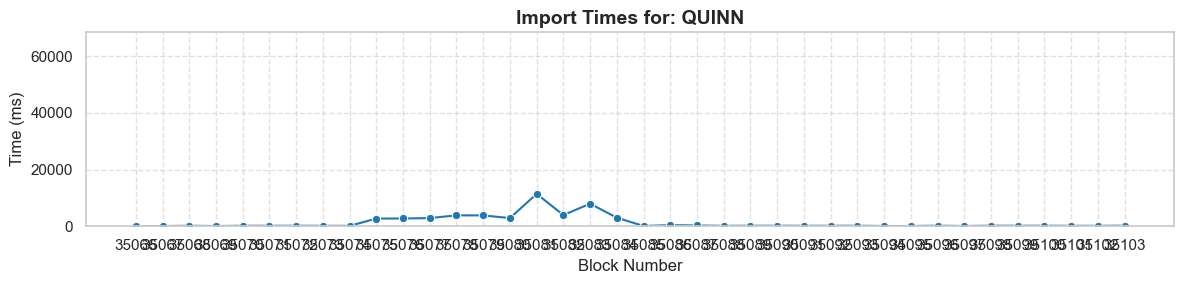

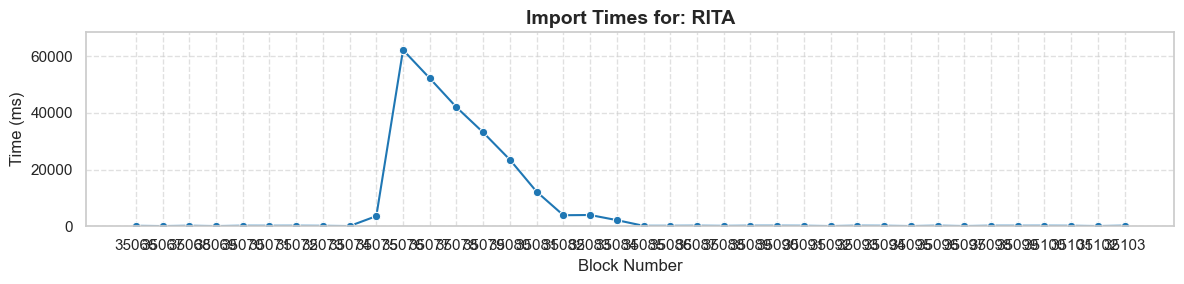

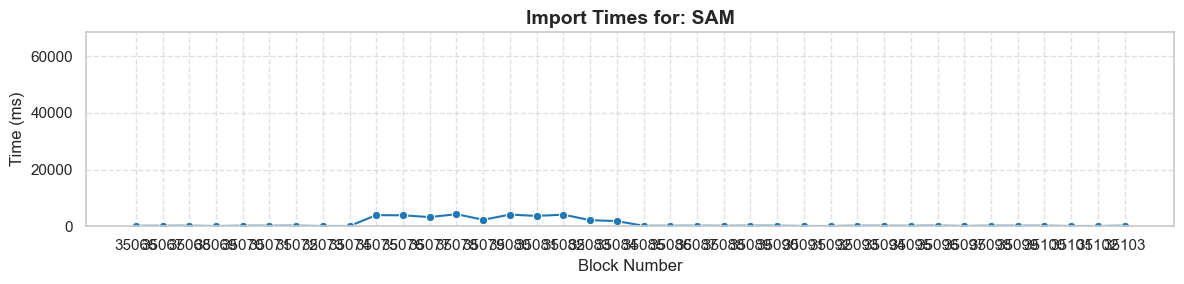

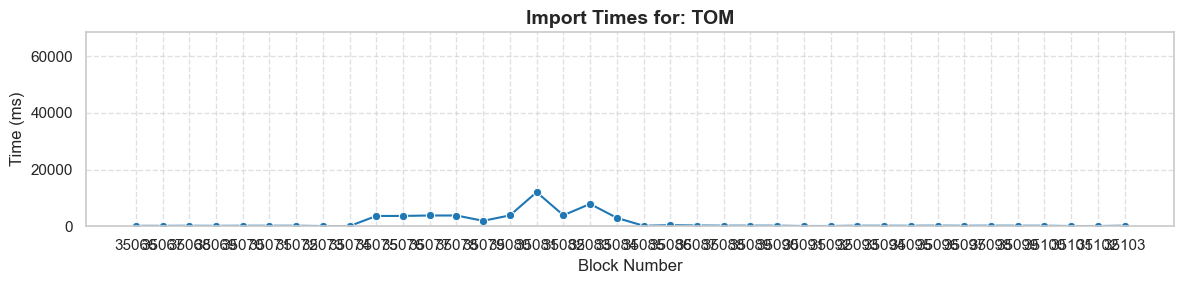

In [17]:
# ---------------------------------------------------------
# Plot block import times per node
# ---------------------------------------------------------


# 1. PRE-CALCULATE THE Y-AXIS LIMIT
# Find the max value in the whole dataset and add a 10% buffer for visual spacing
max_val = df['ImportTime_ms'].max()
global_y_limit = max_val * 1.1 

# Get a list of all unique nodes and sort them alphabetically
nodes = sorted(df['Node'].unique())

# Loop through each node and create a separate graph
for node in nodes:
    # Filter the data for just this node
    node_data = df[df['Node'] == node]
    
    # Create a new figure for this node
    plt.figure(figsize=(12, 3)) 
    
    # Plot the line
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ImportTime_ms", 
        marker="o",
        color='tab:blue',
        errorbar=None
    )
    
    # Formatting
    plt.title(f"Import Times for: {node.upper()}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # --- CRITICAL CHANGE HERE ---
    # Force every plot to use the same 0 to Global Max scale
    plt.ylim(0, global_y_limit)
    # ----------------------------
    
    # Ensure X-axis shows every block integer (if list isn't too long)
    if len(df["Block"].unique()) < 50:
        plt.xticks(df["Block"].unique())
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Display the graph
    plt.show()






# Block Size Analysis

This notebook analyzes blockchain block sizes from CSV data generated by the block size benchmarking scripts.

## Setup

First, generate data using the block size analysis script:
```bash
python3 ../block_size_benchmarks/analyze_block_sizes.py --url ws://127.0.0.1:9944 --latest-n 100
```

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## Load Data

Update the path to your CSV file:

In [ ]:
# Update this path to your CSV file
csv_file = "../block_size_benchmarks/block_size_analysis_latest_100/block_sizes.csv"

# Load data
df = pd.read_csv(csv_file)

# Display basic info
print(f"Loaded {len(df)} blocks")
print(f"Block range: #{df['block_number'].min()} to #{df['block_number'].max()}")
df.head()

## Summary Statistics

In [ ]:
print("=" * 60)
print("BLOCK SIZE STATISTICS")
print("=" * 60)
print(f"Average block size:     {df['size_kb'].mean():.2f} KB")
print(f"Median block size:      {df['size_kb'].median():.2f} KB")
print(f"Min block size:         {df['size_kb'].min():.2f} KB")
print(f"Max block size:         {df['size_kb'].max():.2f} KB")
print(f"Std deviation:          {df['size_kb'].std():.2f} KB")
print(f"Total data:             {df['size_mb'].sum():.2f} MB")
print()
print("EXTRINSIC STATISTICS")
print("=" * 60)
print(f"Total extrinsics:       {df['extrinsic_count'].sum():,}")
print(f"Average per block:      {df['extrinsic_count'].mean():.1f}")
print(f"Min per block:          {df['extrinsic_count'].min()}")
print(f"Max per block:          {df['extrinsic_count'].max()}")

## Block Size Over Time

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df['block_number'], df['size_kb'], marker='o', markersize=4, linewidth=1.5, alpha=0.7)
ax.axhline(y=df['size_kb'].mean(), color='r', linestyle='--', linewidth=2, label=f"Average: {df['size_kb'].mean():.2f} KB")

ax.set_xlabel('Block Number', fontsize=12)
ax.set_ylabel('Block Size (KB)', fontsize=12)
ax.set_title('Block Size Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Block Size Distribution

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
ax1.hist(df['size_kb'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(df['size_kb'].mean(), color='r', linestyle='--', linewidth=2, label='Mean')
ax1.axvline(df['size_kb'].median(), color='g', linestyle='--', linewidth=2, label='Median')
ax1.set_xlabel('Block Size (KB)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Block Size Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Box plot
ax2.boxplot(df['size_kb'], vert=True, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Block Size (KB)', fontsize=12)
ax2.set_title('Block Size Box Plot', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Block Size vs Extrinsic Count

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(df['extrinsic_count'], df['size_kb'], alpha=0.6, s=60, edgecolors='black', linewidth=0.5)

# Add trend line
if len(df) > 1:
    z = np.polyfit(df['extrinsic_count'], df['size_kb'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df['extrinsic_count'].min(), df['extrinsic_count'].max(), 100)
    ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label=f'Trend: y = {z[0]:.2f}x + {z[1]:.2f}')

ax.set_xlabel('Number of Extrinsics', fontsize=12)
ax.set_ylabel('Block Size (KB)', fontsize=12)
ax.set_title('Block Size vs Number of Extrinsics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Top 10 Largest Blocks

In [ ]:
top_blocks = df.nlargest(10, 'size_kb')[['block_number', 'size_kb', 'extrinsic_count']]
top_blocks.reset_index(drop=True, inplace=True)
top_blocks.index = top_blocks.index + 1
print("Top 10 Largest Blocks:")
print(top_blocks.to_string())

## Size per Extrinsic Analysis

In [ ]:
# Calculate average size per extrinsic for each block
df['size_per_extrinsic'] = df['size_kb'] / df['extrinsic_count'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df['block_number'], df['size_per_extrinsic'], marker='o', markersize=4, linewidth=1.5, alpha=0.7, color='orange')
ax.axhline(y=df['size_per_extrinsic'].mean(), color='r', linestyle='--', linewidth=2, 
           label=f"Average: {df['size_per_extrinsic'].mean():.2f} KB/extrinsic")

ax.set_xlabel('Block Number', fontsize=12)
ax.set_ylabel('KB per Extrinsic', fontsize=12)
ax.set_title('Average Size per Extrinsic Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Custom Analysis

Add your own analysis cells below:

In [ ]:
# Your custom analysis here